In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.style.use("../fopraplot.mplstyle")
data = np.genfromtxt("./data/hom_data.txt", skip_header=5)

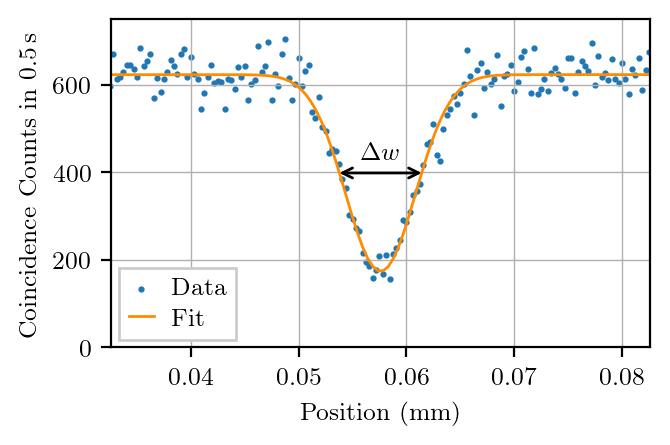

In [78]:
def gauss_fit(x, A, B, x0, s):
    return A * ( 1 - B*np.exp(-(x-x0)**2 / (2*s**2)) )

def sech_fit(x, A, B, x0, s):
    return A * ( 1 - B*np.cosh((x-x0)/s)**(-2) )

sigma = data[:,5]**(0.5) # variance of counts proportional to counts
params, pcov = curve_fit(gauss_fit, data[:,0], data[:,5], p0=(600, 0.95, 0.06, 0.01), 
                         sigma=sigma)

fwhm = 2 * np.sqrt(2*np.log(2)) * params[3]
fwhm_y = params[0] * (1 - params[1]/2)
fwhm_err = 2 * np.sqrt(2*np.log(2)) * pcov[3,3]**0.5


xs = np.linspace(data[0,0], data[-1, 0], 200)

fig, ax = plt.subplots()
ax.scatter(data[:,0], data[:,5], marker=".", label="Data")
ax.plot(xs, gauss_fit(xs, *params), color="darkorange", label="Fit")

ax.annotate("", xy=(params[2]-fwhm/2, fwhm_y), xytext=(params[2]+fwhm/2, fwhm_y), 
            arrowprops=dict(arrowstyle="<->", shrinkA=0, shrinkB=0) )
ax.text(params[2], 430, r"$\Delta w$", horizontalalignment="center")

ax.set(xlabel="Position (mm)", ylabel=r"Coincidence Counts in \qty{0.5}{\s}",
       xlim=(params[2]-0.025, params[2]+0.025), ylim=(0, 750))
ax.legend()
ax.grid()

In [79]:
fig.savefig("./figs/hom_dip.pdf")

In [80]:
vis = params[1]
vis_err = pcov[1, 1]**0.5
print(f"HOM Visibility: ({vis*100:.1f} +- {vis_err*100:.1f})%",
      f"\nHOM dip width: ({fwhm*1e3:.1f} +- {fwhm_err*1e3:.1f}) micro meter")

HOM Visibility: (72.1 +- 1.0)% 
HOM dip width: (7.6 +- 0.2) micro meter
